# 02 — Feature Engineering

This notebook performs:
1. **Feature-to-feature Pearson correlation** to remove redundant features (|r| >= 0.95)
2. **Feature-to-target Pearson correlation** to identify and drop features with no linear relationship to any malware category
3. **PCA (Principal Component Analysis)** for dimensionality reduction and feature extraction

Outputs are saved to `../data/processed/` for use in notebook 03.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", 60)
sns.set_style("whitegrid")

## 1. Load and Prepare Data

Replicate the cleaning and split from notebook 01 so this notebook is self-contained.

In [2]:
# Load both CSVs and combine
df_benign = pd.read_csv("../data/raw/All Benign Samples-combined.csv")
df_malware = pd.read_csv("../data/raw/All Malware Samples-Combined2006-2021.csv")
df = pd.concat([df_benign, df_malware], ignore_index=True)
df.columns = df.columns.str.strip()

# Extract category and save Year before dropping metadata
df["category"] = df["Category"].apply(lambda x: x.split("-")[0])
sample_year = df["Year"].copy()
df.drop(columns=["Category", "Year", "Month"], inplace=True)

# Separate features and target
feature_cols = [c for c in df.columns if c not in ["category", "Class"]]
X = df[feature_cols]
y = df["category"]

# Drop redundant svcscan feature (highly correlated with svcscan.nservices, r=0.956)
X = X.drop(columns=["svcscan.shared_process_services"], errors="ignore")

# === Split 1: Random stratified (same as notebook 01) ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# === Split 2: Temporal (train pre-2020, test 2020-2021) ===
is_benign = sample_year.isna()
is_train_malware = sample_year < 2020
is_test_malware = sample_year >= 2020

benign_idx = df.index[is_benign]
benign_train_idx, benign_test_idx = train_test_split(
    benign_idx, test_size=0.2, random_state=42
)

temporal_train_idx = df.index[is_train_malware].append(benign_train_idx)
temporal_test_idx = df.index[is_test_malware].append(benign_test_idx)

X_train_temp = X.loc[temporal_train_idx]
X_test_temp = X.loc[temporal_test_idx]
y_train_temp = y.loc[temporal_train_idx]
y_test_temp = y.loc[temporal_test_idx]

print(f"Features: {X.shape[1]}")
print(f"\nRandom split  — Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Temporal split — Train: {len(X_train_temp)} | Test: {len(X_test_temp)}")

Features: 54

Random split  — Train: 46534 | Test: 11634
Temporal split — Train: 39964 | Test: 18204


## 2. Pearson Correlation — Feature-to-Feature Redundancy

Identify highly correlated feature pairs (|r| >= 0.95). When two features carry nearly identical information, keeping both adds noise without predictive value.

In [3]:
# Remove constant (zero-variance) features — they produce NaN in correlation and carry no signal
zero_var_cols = X_train.columns[X_train.var() == 0].tolist()
if zero_var_cols:
    print(f"Dropping {len(zero_var_cols)} constant features: {zero_var_cols}")
    X_train = X_train.drop(columns=zero_var_cols)
    X_test = X_test.drop(columns=zero_var_cols)
    X_train_temp = X_train_temp.drop(columns=zero_var_cols)
    X_test_temp = X_test_temp.drop(columns=zero_var_cols)
else:
    print("No constant features found.")

print(f"Features remaining: {X_train.shape[1]}")

Dropping 3 constant features: ['pslist.nprocs64bit', 'handles.nport', 'svcscan.interactive_process_services']
Features remaining: 51


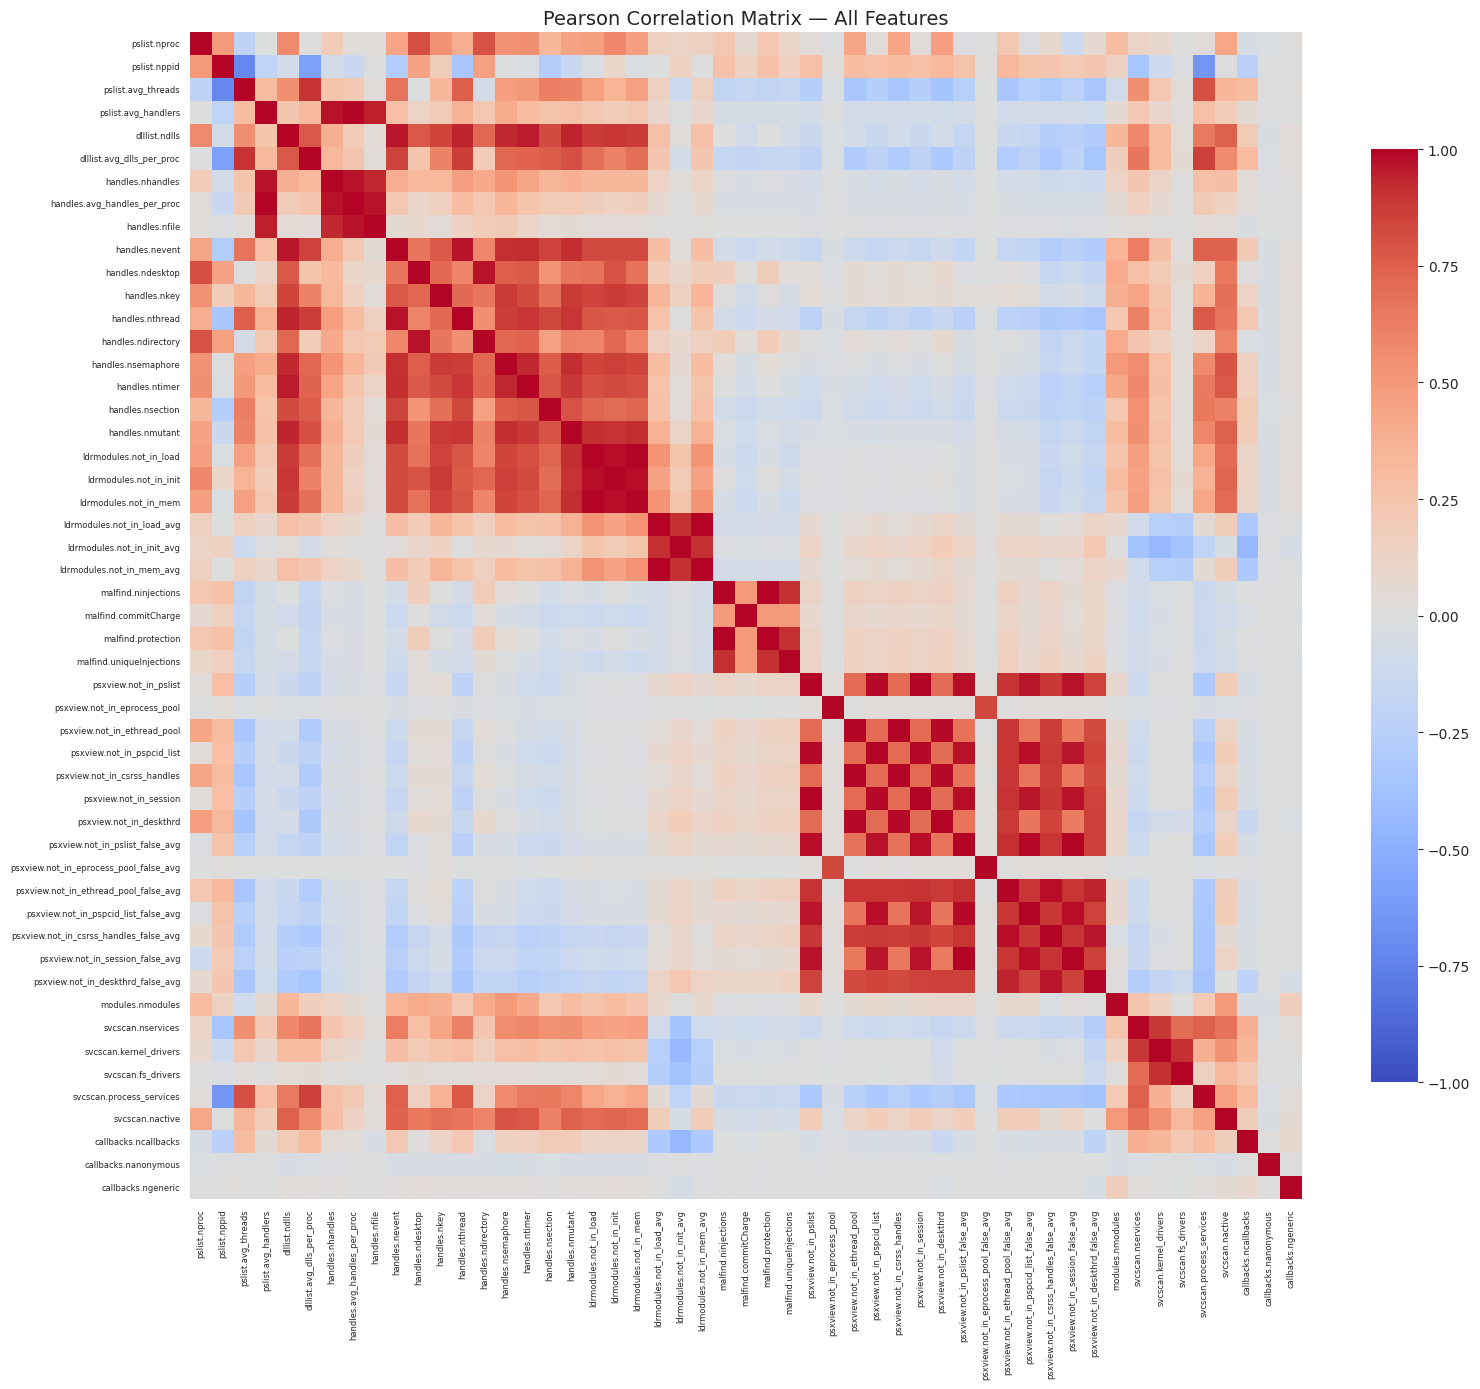

In [4]:
corr = X_train.corr(method="pearson")

# Full correlation heatmap
fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            xticklabels=True, yticklabels=True, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Pearson Correlation Matrix — All Features", fontsize=14)
ax.tick_params(axis="both", labelsize=6)
plt.tight_layout()
plt.show()

In [5]:
# Find highly correlated CROSS-MODULE pairs (|r| >= 0.95)
# Intra-module correlations (e.g. handles.X vs handles.Y) are expected — skip them
threshold = 0.95
high_corr_pairs = []

def get_module(feat_name):
    """Extract scan module prefix (e.g. 'handles' from 'handles.nport')."""
    return feat_name.split(".")[0]

for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        f1, f2 = corr.columns[i], corr.columns[j]
        if get_module(f1) == get_module(f2):
            continue  # same module — skip
        if abs(corr.iloc[i, j]) >= threshold:
            high_corr_pairs.append((f1, f2, round(corr.iloc[i, j], 4)))

high_corr_df = pd.DataFrame(high_corr_pairs, columns=["Feature_1", "Feature_2", "Correlation"])
high_corr_df = high_corr_df.sort_values("Correlation", key=abs, ascending=False).reset_index(drop=True)

print(f"Cross-module pairs with |r| >= {threshold}: {len(high_corr_df)}")
high_corr_df

Cross-module pairs with |r| >= 0.95: 5


,Feature_1,Feature_2,Correlation
0,pslist.avg_handlers,handles.avg_handles_per_proc,0.9937
1,pslist.avg_handlers,handles.nhandles,0.9762
2,dlllist.ndlls,handles.nevent,0.9654
3,dlllist.ndlls,handles.ntimer,0.9536
4,pslist.avg_handlers,handles.nfile,0.9504


In [6]:
# Drop one feature from each highly correlated pair
# Strategy: drop the feature with higher mean abs correlation to all others (more redundant)

to_drop = set()
for _, row in high_corr_df.iterrows():
    f1, f2 = row["Feature_1"], row["Feature_2"]
    if f1 in to_drop or f2 in to_drop:
        continue
    mean_corr_f1 = corr[f1].drop(f1).abs().mean()
    mean_corr_f2 = corr[f2].drop(f2).abs().mean()
    if mean_corr_f1 >= mean_corr_f2:
        to_drop.add(f1)
    else:
        to_drop.add(f2)

print(f"Features to drop ({len(to_drop)}): {sorted(to_drop)}")
print(f"Features remaining: {X_train.shape[1] - len(to_drop)}")

Features to drop (3): ['dlllist.ndlls', 'handles.nevent', 'pslist.avg_handlers']
Features remaining: 48


Shape after correlation filter: (46534, 48)


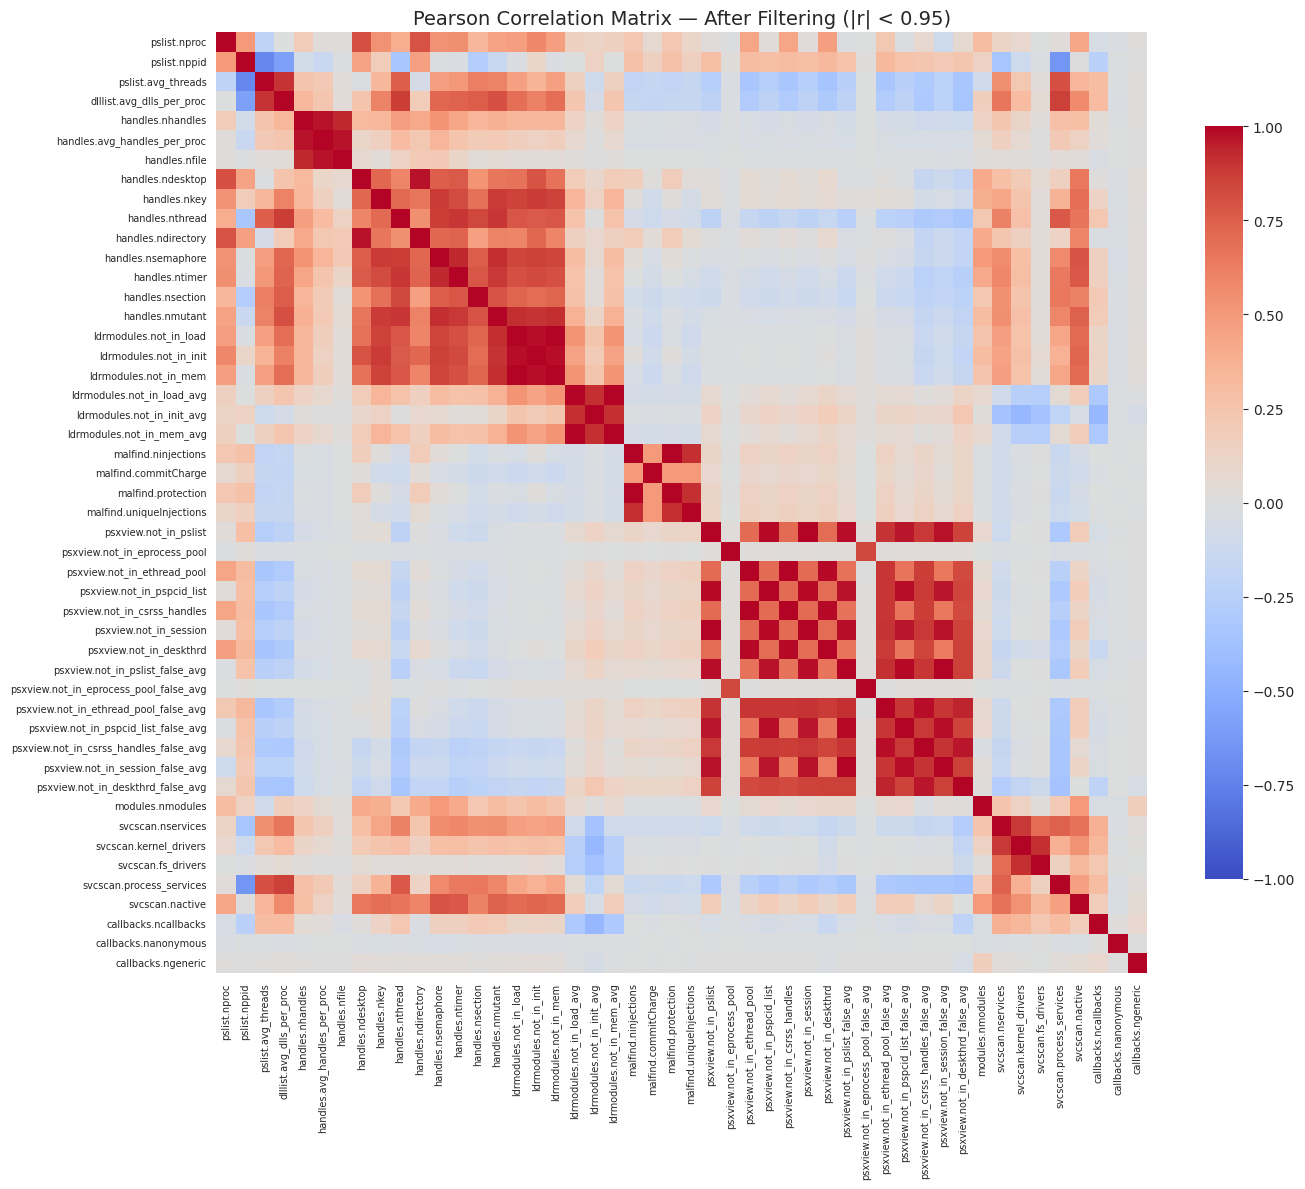

In [7]:
# Apply the filter to both splits
X_train_filtered = X_train.drop(columns=to_drop)
X_test_filtered = X_test.drop(columns=to_drop)
X_train_temp_filtered = X_train_temp.drop(columns=to_drop)
X_test_temp_filtered = X_test_temp.drop(columns=to_drop)

print(f"Shape after correlation filter: {X_train_filtered.shape}")

# Show the cleaned correlation matrix
corr_filtered = X_train_filtered.corr(method="pearson")
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_filtered, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            xticklabels=True, yticklabels=True, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Pearson Correlation Matrix — After Filtering (|r| < 0.95)", fontsize=14)
ax.tick_params(axis="both", labelsize=7)
plt.tight_layout()
plt.show()

## 3. Pearson Correlation — Feature-to-Target Relevance

Measure how strongly each feature correlates with the target classes. One-hot encode `category` (Benign, Ransomware, Spyware, Trojan), compute Pearson |r| between each feature and each class column, then take the **max** — this captures features that distinguish *any* class, not just one.

Features with near-zero max |r| have no linear relationship with any category and are candidates for removal.

In [8]:
# One-hot encode multi-class target
dummies = pd.get_dummies(y_train).reindex(X_train_filtered.index)

# Max |r| across all classes for each feature
feat_target_corr = X_train_filtered.apply(
    lambda col: dummies.corrwith(col).abs().max()
).sort_values(ascending=False)

# Also store per-class correlations for the heatmap
per_class_corr = pd.DataFrame({
    cls: X_train_filtered.corrwith(dummies[cls])
    for cls in dummies.columns
})

# Display ranked results
print("Feature relevance (max |r| across all classes):\n")
print(feat_target_corr.to_string())
print(f"\nMost relevant:  {feat_target_corr.idxmax()} (|r|={feat_target_corr.max():.4f})")
print(f"Least relevant: {feat_target_corr.idxmin()} (|r|={feat_target_corr.min():.4f})")

Feature relevance (max |r| across all classes):

dlllist.avg_dlls_per_proc                 0.908367
handles.nthread                           0.871455
handles.nmutant                           0.854841
handles.nsection                          0.802185
pslist.avg_threads                        0.790644
ldrmodules.not_in_load                    0.785789
ldrmodules.not_in_mem                     0.785732
handles.ntimer                            0.781159
handles.nsemaphore                        0.766179
svcscan.process_services                  0.762763
ldrmodules.not_in_init                    0.714869
handles.nkey                              0.695585
svcscan.nactive                           0.652534
svcscan.nservices                         0.630564
pslist.nppid                              0.422854
handles.ndesktop                          0.390380
handles.nhandles                          0.346758
ldrmodules.not_in_load_avg                0.339835
ldrmodules.not_in_mem_avg        

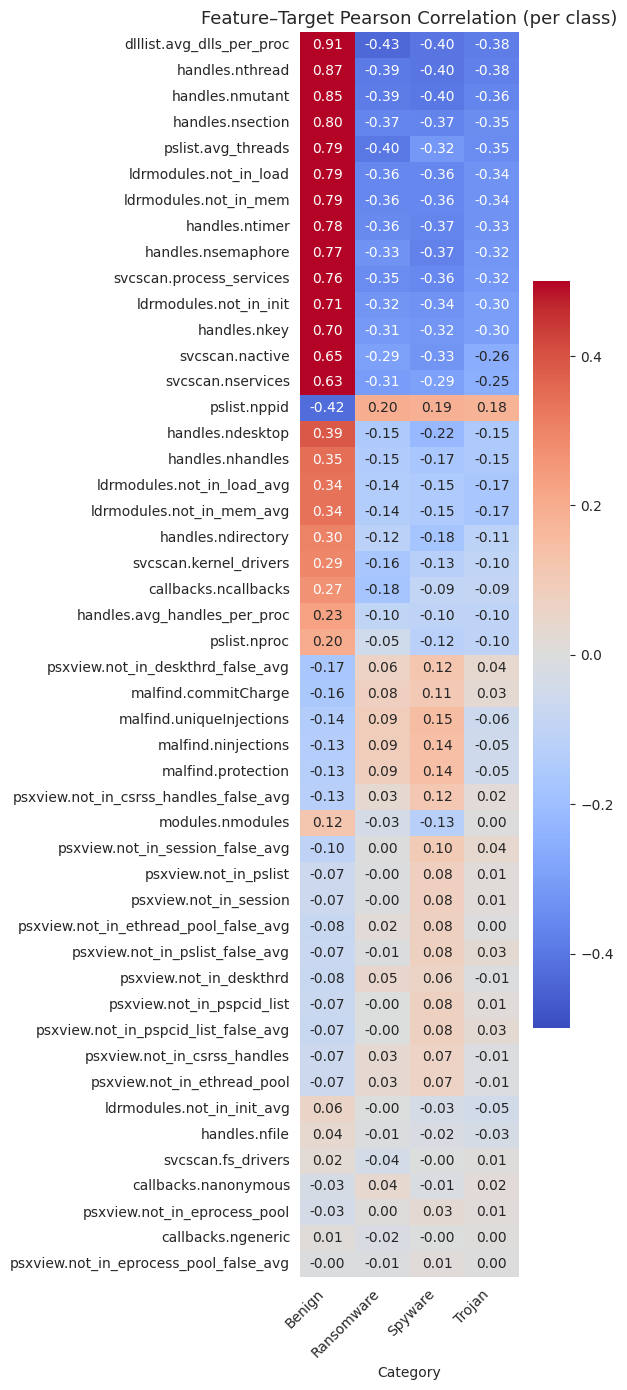

In [9]:
# Heatmap: per-class Pearson correlation for all features
fig, ax = plt.subplots(figsize=(6, 14))
sns.heatmap(per_class_corr.loc[feat_target_corr.index], cmap="coolwarm", center=0,
            vmin=-0.5, vmax=0.5, annot=True, fmt=".2f", ax=ax,
            cbar_kws={"shrink": 0.6})
ax.set_title("Feature–Target Pearson Correlation (per class)", fontsize=13)
ax.set_xlabel("Category")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [10]:
# Drop features with near-zero target correlation (max |r| < 0.05)
low_relevance_cols = feat_target_corr[feat_target_corr < 0.05].index.tolist()

if low_relevance_cols:
    X_train_filtered = X_train_filtered.drop(columns=low_relevance_cols, errors='ignore')
    X_test_filtered = X_test_filtered.drop(columns=low_relevance_cols, errors='ignore')
    X_train_temp_filtered = X_train_temp_filtered.drop(columns=low_relevance_cols, errors='ignore')
    X_test_temp_filtered = X_test_temp_filtered.drop(columns=low_relevance_cols, errors='ignore')
    print(f"Dropped {len(low_relevance_cols)} low-relevance features: {low_relevance_cols}")
else:
    print("No features below threshold — all retained.")

print(f"Features remaining: {X_train_filtered.shape[1]}")

Dropped 6 low-relevance features: ['handles.nfile', 'svcscan.fs_drivers', 'callbacks.nanonymous', 'psxview.not_in_eprocess_pool', 'callbacks.ngeneric', 'psxview.not_in_eprocess_pool_false_avg']
Features remaining: 42


## 4. Feature Scaling

Scale the filtered features using `RobustScaler` before PCA (PCA is sensitive to feature magnitudes).

In [11]:
# Log-transform features that would break or dominate after scaling
# Catches: zero-IQR columns AND heavily skewed columns (|skewness| > 10)
from scipy.stats import iqr, skew

log_cols = set()
for c in X_train_filtered.columns:
    if iqr(X_train_filtered[c]) == 0 or abs(skew(X_train_filtered[c])) > 10:
        log_cols.add(c)

log_cols = sorted(log_cols)
if log_cols:
    print(f"Applying log1p to {len(log_cols)} skewed/zero-IQR features: {log_cols}")
    for c in log_cols:
        X_train_filtered[c] = np.log1p(X_train_filtered[c].abs()) * np.sign(X_train_filtered[c])
        X_test_filtered[c] = np.log1p(X_test_filtered[c].abs()) * np.sign(X_test_filtered[c])
        X_train_temp_filtered[c] = np.log1p(X_train_temp_filtered[c].abs()) * np.sign(X_train_temp_filtered[c])
        X_test_temp_filtered[c] = np.log1p(X_test_temp_filtered[c].abs()) * np.sign(X_test_temp_filtered[c])

# Drop features with near-zero std after scaling (std < 0.01 means no useful spread)
low_std_cols = [c for c in X_train_filtered.columns if X_train_filtered[c].std() < 0.01]
if low_std_cols:
    print(f"Dropping {len(low_std_cols)} near-constant features (std < 0.01): {low_std_cols}")
    X_train_filtered = X_train_filtered.drop(columns=low_std_cols)
    X_test_filtered = X_test_filtered.drop(columns=low_std_cols)
    X_train_temp_filtered = X_train_temp_filtered.drop(columns=low_std_cols)
    X_test_temp_filtered = X_test_temp_filtered.drop(columns=low_std_cols)

# Scale random split
scaler = RobustScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_filtered),
    columns=X_train_filtered.columns, index=X_train_filtered.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_filtered),
    columns=X_test_filtered.columns, index=X_test_filtered.index
)

# Scale temporal split (fit on temporal train only)
scaler_temp = RobustScaler()
X_train_temp_scaled = pd.DataFrame(
    scaler_temp.fit_transform(X_train_temp_filtered),
    columns=X_train_temp_filtered.columns, index=X_train_temp_filtered.index
)
X_test_temp_scaled = pd.DataFrame(
    scaler_temp.transform(X_test_temp_filtered),
    columns=X_test_temp_filtered.columns, index=X_test_temp_filtered.index
)

print(f"\nScaled shape (random):   {X_train_scaled.shape}")
print(f"Scaled shape (temporal): {X_train_temp_scaled.shape}")

Applying log1p to 15 skewed/zero-IQR features: ['handles.avg_handles_per_proc', 'handles.nhandles', 'handles.nsection', 'ldrmodules.not_in_init_avg', 'ldrmodules.not_in_load_avg', 'ldrmodules.not_in_mem_avg', 'malfind.commitCharge', 'malfind.ninjections', 'malfind.protection', 'modules.nmodules', 'psxview.not_in_csrss_handles', 'psxview.not_in_deskthrd', 'psxview.not_in_ethread_pool', 'svcscan.kernel_drivers', 'svcscan.nservices']
Dropping 4 near-constant features (std < 0.01): ['ldrmodules.not_in_load_avg', 'ldrmodules.not_in_init_avg', 'ldrmodules.not_in_mem_avg', 'modules.nmodules']

Scaled shape (random):   (46534, 38)
Scaled shape (temporal): (39964, 38)


In [14]:
# Sanity check: verify scaling worked — all features should have mean ≈ 0, std ≈ 1
print(X_train_scaled.describe().loc[['mean', 'std']].to_string())
print(f"\nMax abs mean: {X_train_scaled.mean().abs().max():.6f}")
print(f"Std range: [{X_train_scaled.std().min():.6f}, {X_train_scaled.std().max():.6f}]")

      pslist.nproc  pslist.nppid  pslist.avg_threads  dlllist.avg_dlls_per_proc  handles.nhandles  handles.avg_handles_per_proc  handles.ndesktop  handles.nkey  handles.nthread  handles.ndirectory  handles.nsemaphore  handles.ntimer  handles.nsection  handles.nmutant  ldrmodules.not_in_load  ldrmodules.not_in_init  ldrmodules.not_in_mem  malfind.ninjections  malfind.commitCharge  malfind.protection  malfind.uniqueInjections  psxview.not_in_pslist  psxview.not_in_ethread_pool  psxview.not_in_pspcid_list  psxview.not_in_csrss_handles  psxview.not_in_session  psxview.not_in_deskthrd  psxview.not_in_pslist_false_avg  psxview.not_in_ethread_pool_false_avg  psxview.not_in_pspcid_list_false_avg  psxview.not_in_csrss_handles_false_avg  psxview.not_in_session_false_avg  psxview.not_in_deskthrd_false_avg  svcscan.nservices  svcscan.kernel_drivers  svcscan.process_services  svcscan.shared_process_services  svcscan.nactive  callbacks.ncallbacks
mean      0.130356     -0.073731            0.113080 

## 5. PCA — Feature Extraction

Apply PCA to reduce dimensionality. First, fit on all components to find the optimal number via explained variance, then extract the final reduced set.

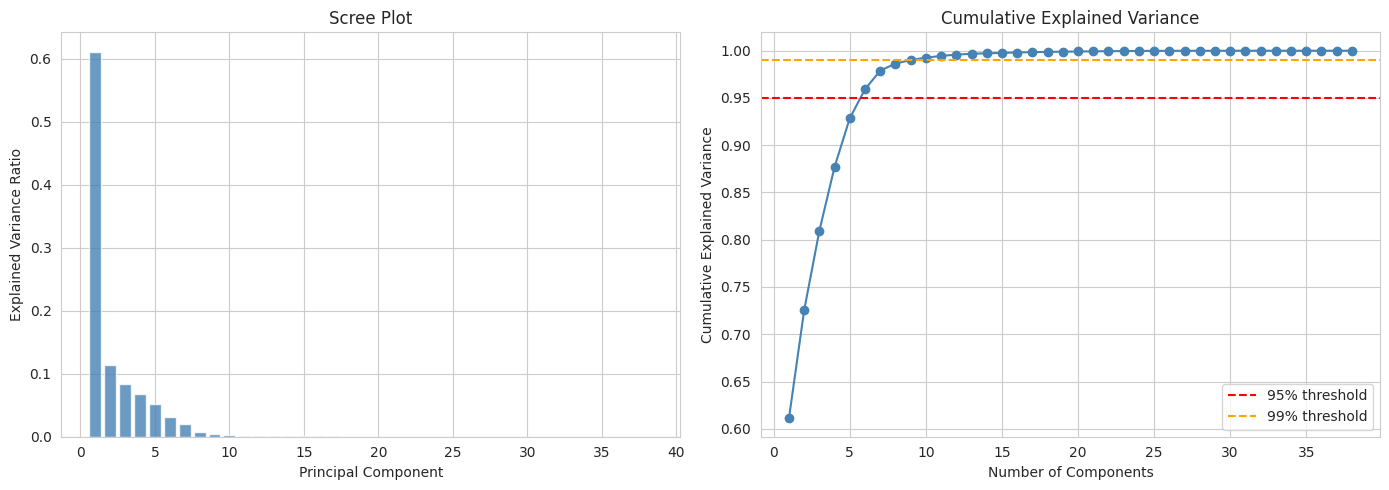

Components for 95% variance: 6
Components for 99% variance: 9


In [12]:
# Fit PCA on all components to analyze explained variance
pca_full = PCA(random_state=42)
pca_full.fit(X_train_scaled)

cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_, color="steelblue", alpha=0.8)
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")
axes[0].set_title("Scree Plot")

# Cumulative variance
axes[1].plot(range(1, len(cumulative_var) + 1), cumulative_var, "o-", color="steelblue")
axes[1].axhline(y=0.95, color="red", linestyle="--", label="95% threshold")
axes[1].axhline(y=0.99, color="orange", linestyle="--", label="99% threshold")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance")
axes[1].set_title("Cumulative Explained Variance")
axes[1].legend()

plt.tight_layout()
plt.show()

# Report thresholds
n_95 = np.argmax(cumulative_var >= 0.95) + 1
n_99 = np.argmax(cumulative_var >= 0.99) + 1
print(f"Components for 95% variance: {n_95}")
print(f"Components for 99% variance: {n_99}")

In [13]:
# Apply PCA with 95% explained variance — random split
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

pca_cols = [f"PC{i+1}" for i in range(X_train_pca.shape[1])]
X_train_pca_df = pd.DataFrame(X_train_pca, columns=pca_cols, index=X_train_scaled.index)
X_test_pca_df = pd.DataFrame(X_test_pca, columns=pca_cols, index=X_test_scaled.index)

# Apply PCA — temporal split (fit on temporal train)
pca_temp = PCA(n_components=0.95, random_state=42)
X_train_temp_pca = pca_temp.fit_transform(X_train_temp_scaled)
X_test_temp_pca = pca_temp.transform(X_test_temp_scaled)

pca_temp_cols = [f"PC{i+1}" for i in range(X_train_temp_pca.shape[1])]
X_train_temp_pca_df = pd.DataFrame(X_train_temp_pca, columns=pca_temp_cols, index=X_train_temp_scaled.index)
X_test_temp_pca_df = pd.DataFrame(X_test_temp_pca, columns=pca_temp_cols, index=X_test_temp_scaled.index)

print(f"Random split:   {X_train_scaled.shape[1]} -> {X_train_pca_df.shape[1]} components ({pca.explained_variance_ratio_.sum():.4f} variance)")
print(f"Temporal split:  {X_train_temp_scaled.shape[1]} -> {X_train_temp_pca_df.shape[1]} components ({pca_temp.explained_variance_ratio_.sum():.4f} variance)")

Random split:   38 -> 6 components (0.9592 variance)
Temporal split:  38 -> 7 components (0.9716 variance)


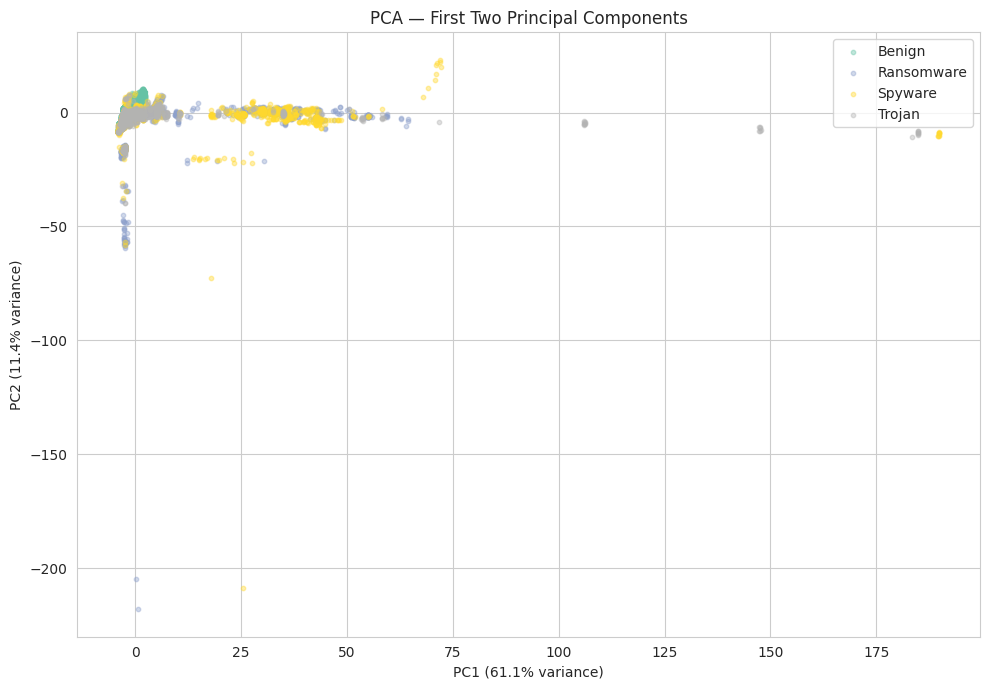

In [14]:
# Visualize first 2 principal components colored by class
if X_train_pca_df.shape[1] >= 2:
    fig, ax = plt.subplots(figsize=(10, 7))
    categories = sorted(y_train.unique())
    colors = plt.cm.Set2(np.linspace(0, 1, len(categories)))

    pc1, pc2 = X_train_pca_df.columns[0], X_train_pca_df.columns[1]
    for cat, color in zip(categories, colors):
        mask = y_train == cat
        ax.scatter(X_train_pca_df.loc[mask, pc1],
                   X_train_pca_df.loc[mask, pc2],
                   label=cat, alpha=0.4, s=10, color=color)

    ax.set_xlabel(f"{pc1} ({pca.explained_variance_ratio_[0]:.1%} variance)")
    ax.set_ylabel(f"{pc2} ({pca.explained_variance_ratio_[1]:.1%} variance)")
    ax.set_title("PCA — First Two Principal Components")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f"Only {X_train_pca_df.shape[1]} component(s) retained — skipping 2D scatter plot.")

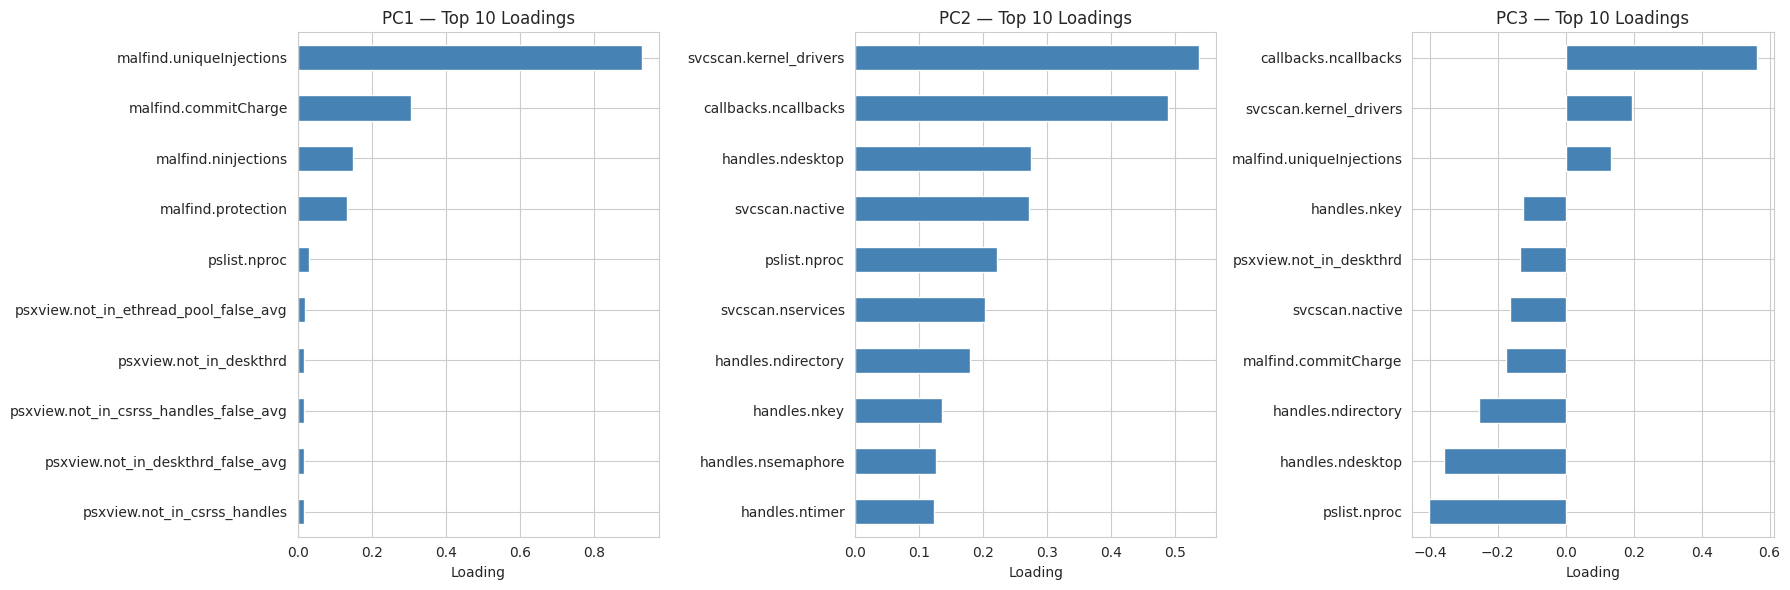

In [15]:
# Top feature loadings for first PCs (up to 3)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=pca_cols,
    index=X_train_scaled.columns
)

n_plots = min(3, len(pca_cols))
fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 6), squeeze=False)
for i in range(n_plots):
    ax = axes[0, i]
    pc = pca_cols[i]
    top = loadings[pc].abs().nlargest(10)
    loadings[pc].loc[top.index].sort_values().plot.barh(ax=ax, color="steelblue")
    ax.set_title(f"{pc} — Top 10 Loadings")
    ax.set_xlabel("Loading")

plt.tight_layout()
plt.show()

## 6. Encode Labels and Save Outputs

Save three feature sets for model comparison in notebook 03:
1. **Correlation-filtered** (scaled, redundant + low-relevance features removed)
2. **PCA-transformed** (dimensionality-reduced)
3. **Labels** (encoded)

In [16]:
import joblib
import os

# Encode labels for both splits
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

le_temp = LabelEncoder()
y_train_temp_encoded = le_temp.fit_transform(y_train_temp)
y_test_temp_encoded = le_temp.transform(y_test_temp)

print("Label mapping:")
for label, idx in zip(le.classes_, range(len(le.classes_))):
    print(f"  {label} -> {idx}")

# Save both splits to separate subdirectories
for split_name, data in [
    ("random", {
        "X_train_filt": X_train_scaled, "X_test_filt": X_test_scaled,
        "X_train_pca": X_train_pca_df, "X_test_pca": X_test_pca_df,
        "y_train_enc": y_train_encoded, "y_test_enc": y_test_encoded,
        "y_train_idx": y_train.index, "y_test_idx": y_test.index,
        "scaler": scaler, "pca": pca, "le": le,
    }),
    ("temporal", {
        "X_train_filt": X_train_temp_scaled, "X_test_filt": X_test_temp_scaled,
        "X_train_pca": X_train_temp_pca_df, "X_test_pca": X_test_temp_pca_df,
        "y_train_enc": y_train_temp_encoded, "y_test_enc": y_test_temp_encoded,
        "y_train_idx": y_train_temp.index, "y_test_idx": y_test_temp.index,
        "scaler": scaler_temp, "pca": pca_temp, "le": le_temp,
    }),
]:
    out = f"../data/processed/{split_name}"
    os.makedirs(out, exist_ok=True)

    data["X_train_filt"].to_csv(f"{out}/X_train_filtered.csv", index=True)
    data["X_test_filt"].to_csv(f"{out}/X_test_filtered.csv", index=True)
    data["X_train_pca"].to_csv(f"{out}/X_train_pca.csv", index=True)
    data["X_test_pca"].to_csv(f"{out}/X_test_pca.csv", index=True)

    pd.Series(data["y_train_enc"], index=data["y_train_idx"], name="label").to_csv(f"{out}/y_train.csv", index=True)
    pd.Series(data["y_test_enc"], index=data["y_test_idx"], name="label").to_csv(f"{out}/y_test.csv", index=True)

    joblib.dump(data["scaler"], f"{out}/scaler.pkl")
    joblib.dump(data["pca"], f"{out}/pca.pkl")
    joblib.dump(data["le"], f"{out}/label_encoder.pkl")

    print(f"\n{split_name}/ — Filtered: {data['X_train_filt'].shape[1]} cols, PCA: {data['X_train_pca'].shape[1]} cols")

# Save shared artifacts
joblib.dump(sorted(to_drop), "../data/processed/dropped_corr_features.pkl")
print("\nDone.")

Label mapping:
  Benign -> 0
  Ransomware -> 1
  Spyware -> 2
  Trojan -> 3

random/ — Filtered: 38 cols, PCA: 6 cols

temporal/ — Filtered: 38 cols, PCA: 7 cols

Done.
